# Import libraries

In [ ]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# Load data

In [88]:
df = pd.read_parquet("../data/ptbxl100_single.parquet")
df.head()

,patient_id,diagnostic_superclass,signal
ecg_id,,,
1,15709.0,NORM,"[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004, ..."
2,13243.0,NORM,"[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, -..."
3,20372.0,NORM,"[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064,..."
4,17014.0,NORM,"[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11, ..."
5,17448.0,NORM,"[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556, ..."


In [89]:
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

X = np.stack(df["signal"].values)
y = df["diagnostic_superclass"]

print(f"X: {X.shape}")
print(f"y: {y.shape}  {y.nunique()} classes")

X: (16244, 12000)
y: (16244,)  5 classes


# Feature Extraction

The paper flattens `(21837, 1000, 12)` *"to (21837, 12000)"*, which is `timemajor`, meaning that, the twelve leads stay interleaved sample by sample, and it is what this
notebook uses.

Following III.D, the script finds the R peaks with `ecg_peaks()`, locates P, Q, S and T around them with `ecg_delineate(method = "peak")`, and assembles the sixteen features, i.e. five peak locations, five peak amplitudes, and six intervals (PQ, ST, QT, PR, RR, QRS).

**Run the first block** if the parquet is already there. **If it is not, run the second block first**, then come back to the first.

We shall note, the additional column is the label, not the features of our interests.

In [ ]:
# Block 1: the parquet already exists.
ORDERING = "timemajor"  # the paper's plain reshape of (n, 1000, 12)
FEATURES_PATH = f"../data/features_{ORDERING}.parquet"

features = pd.read_parquet(FEATURES_PATH)

print(f"loaded {features.shape[0]:,} records from {FEATURES_PATH}")
print(f"features shape is: {features.shape}")
features.head(2)

In [ ]:
# Block 2: No parquet yet. Re-extracts from ptbxl100_single.parquet

# !python ../src/extract_nk_features.py timemajor

In [91]:
shapes = []

for i in range(features.shape[0]):
    for j in range(features.shape[1] - 1):
        # print(i, j, features.iloc[i, j])
        shapes.append(features.iloc[i, j].shape)

np.unique(shapes)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 58, 62, 63, 66, 68, 69, 71, 73, 75, 81])

In [96]:
features.head(2)

,P_loc,Q_loc,R_loc,S_loc,T_loc,P_amp,Q_amp,R_amp,S_amp,T_amp,PQ,ST,QT,PR,QRS,RR,label
ecg_id,,,,,,,,,,,,,,,,,
1,"[264.0, 1363.0, 2484.0, 3063.0, 3469.0, 3589.0...","[275.0, 1379.0, 2495.0, 3204.0, 3483.0, 3594.0...","[280.0, 1384.0, 2500.0, 3207.0, 3485.0, 3600.0...","[283.0, 1386.0, 2502.0, 3208.0, 3549.0, 3603.0...","[287.0, 1403.0, 2519.0, 3481.0, 3623.0, 3623.0...","[0.469, 0.225, 0.351, 0.081, 0.122, 0.227, 0.2...","[0.313, 0.194, 0.276, -0.114, -0.134, 0.059, 0...","[0.248, 0.37, 0.387, 0.082, 0.08, 0.628, 0.641...","[-0.953, -0.367, -0.407, -0.09, -0.056, -0.525...","[0.382, 0.405, 0.414, 0.142, 0.444, 0.444, 0.4...","[11.0, 16.0, 11.0, 141.0, 14.0, 5.0, 5.0, 6.0,...","[4.0, 17.0, 17.0, 273.0, 74.0, 20.0, 20.0, 152...","[12.0, 24.0, 24.0, 277.0, 140.0, 29.0, 29.0, 1...","[16.0, 21.0, 16.0, 144.0, 16.0, 11.0, 11.0, 12...","[8.0, 7.0, 7.0, 4.0, 66.0, 9.0, 9.0, 9.0, 8.0,...","[nan, 1104.0, 1116.0, 707.0, 278.0, 115.0, 111...",NORM
2,"[1183.0, 2769.0, 4387.0, 6029.0, 7525.0, 8965....","[1203.0, 2779.0, 4407.0, 6031.0, 7531.0, 8971....","[1205.0, 2781.0, 4409.0, 6033.0, 7533.0, 8973....","[1207.0, 2791.0, 4411.0, 6036.0, 7536.0, 8976....","[1221.0, 2795.0, 4425.0, 6045.0, 7545.0, 8985....","[0.462, 1.079, 0.368, 0.769, 0.87, 1.225, 0.44...","[-0.865, -2.819, -0.804, -2.221, -2.472, -2.62...","[0.94, 2.188, 0.751, 1.905, 1.753, 2.076, 0.96...","[-2.246, -2.316, -2.11, 0.17, 0.353, 0.053, -2...","[1.86, 0.468, 1.928, 1.707, 1.784, 0.978, 1.69...","[20.0, 10.0, 20.0, 2.0, 6.0, 6.0, 20.0, 10.0]","[14.0, 4.0, 14.0, 9.0, 9.0, 9.0, 2.0, 2.0]","[18.0, 16.0, 18.0, 14.0, 14.0, 14.0, 6.0, 6.0]","[22.0, 12.0, 22.0, 4.0, 8.0, 8.0, 22.0, 12.0]","[4.0, 12.0, 4.0, 5.0, 5.0, 5.0, 4.0, 4.0]","[nan, 1576.0, 1628.0, 1624.0, 1500.0, 1440.0, ...",NORM


## Visualisations waveforms amplitudes and their peak locations

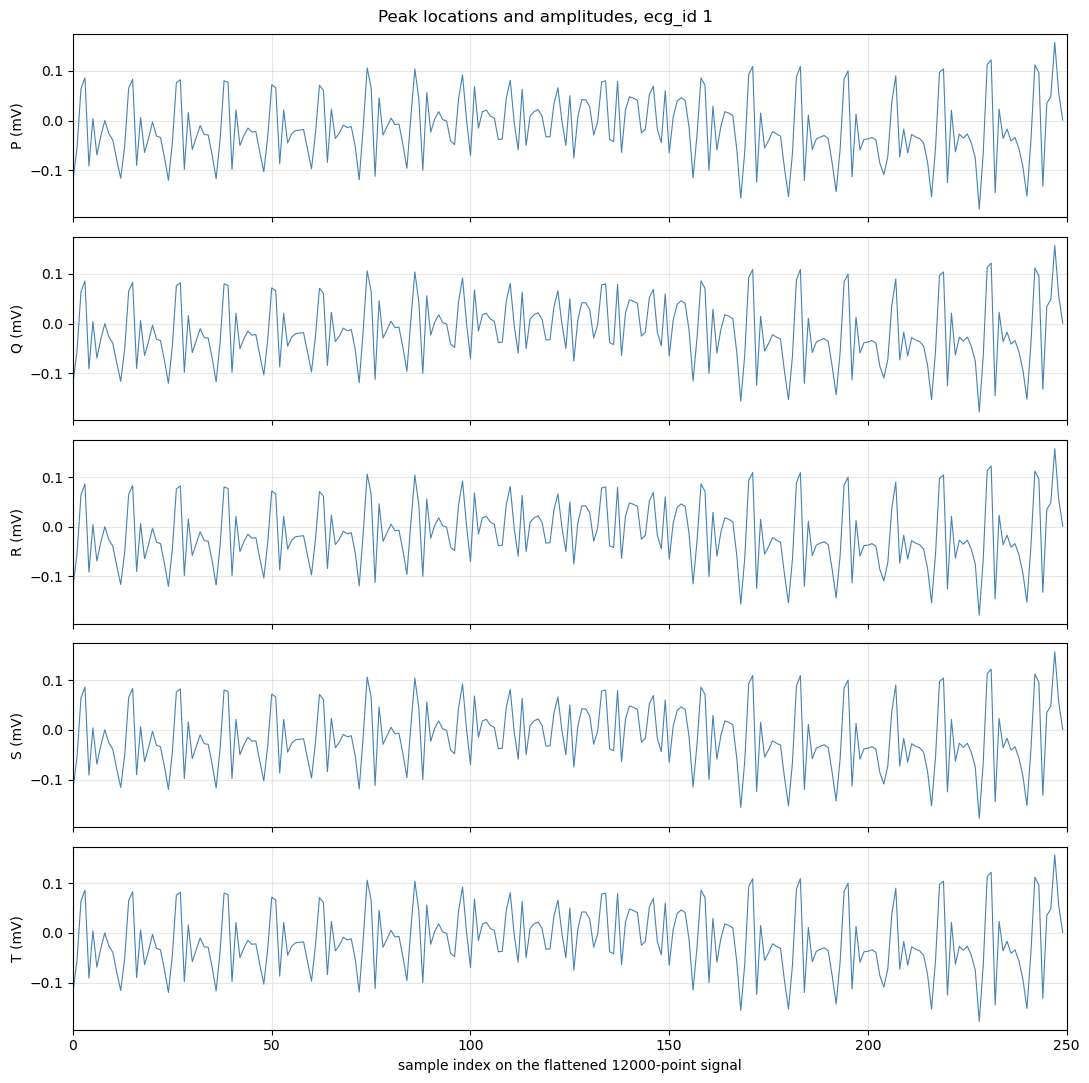

In [97]:
sample = features.iloc[0]

# Visualise five waveform amplitudes (in blue) and their peaks (in red)
WAVE_LABELS = ["P", "Q", "R", "S", "T"]

# `sample` is features.iloc[0]
signal = X[0]
window = 250

fig, axes = plt.subplots(len(WAVE_LABELS), 1, figsize = (11, 11), sharex = True)

for ax, wave in zip(axes, WAVE_LABELS):
    ax.plot(np.arange(window), signal[:window], color = "steelblue", linewidth = 0.8)

    location = sample[f"{wave}_loc"]
    amplitude = sample[f"{wave}_amp"]

    for x in location:
        ax.axvline(x, color = "firebrick", linestyle = "--", linewidth = 0.6, alpha = 1)

    ax.set_ylabel(f"{wave} (mV)")
    ax.set_xlim(0, window)
    ax.grid(alpha = 0.3)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("sample index on the flattened 12000-point signal")
fig.suptitle(f"Peak locations and amplitudes, ecg_id {sample.name}")

plt.tight_layout()
plt.show()

## Visualisations of intervals/segments

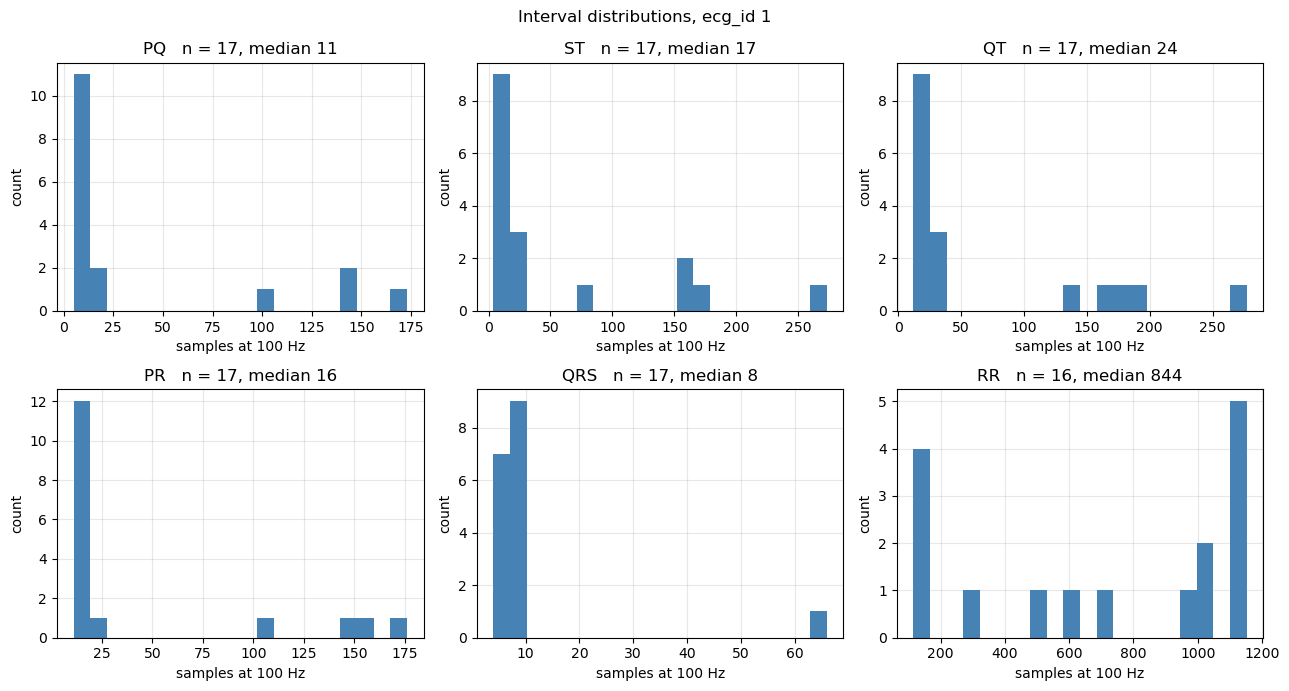

In [98]:
# Visualise the histogram of each interval PQ, ST, ....
INTERVALS = ["PQ", "ST", "QT", "PR", "QRS", "RR"]

fig, axes = plt.subplots(2, 3, figsize = (13, 7))

for ax, name in zip(axes.flatten(), INTERVALS):
    values = sample[name]
    values = values[~np.isnan(values)]

    ax.hist(values, bins = 20, color = "steelblue")

    ax.set_title(f"{name}   n = {len(values)}, median {np.median(values):.0f}")
    ax.set_xlabel("samples at 100 Hz")
    ax.set_ylabel("count")
    ax.grid(alpha = 0.3)
    ax.set_axisbelow(True)

fig.suptitle(f"Interval distributions, ecg_id {sample.name}")

plt.tight_layout()
plt.show()

# Data preparation

## Difficulties verification

Difficulty 1 - subjects with every feature NaN: 280 (1.7%)
Difficulty 2 - distinct feature lengths: 67  (min 0, median 12, max 81)
Also         - records whose 16 features disagree in length: 157
               all of them have exactly one R-peak: True

mean share of NaN within each feature:
RR       0.111
T_loc    0.038
T_amp    0.038
ST       0.038
QT       0.038
S_loc    0.038
S_amp    0.038
QRS      0.038
P_loc    0.038
Q_loc    0.038
P_amp    0.038
Q_amp    0.038
PQ       0.038
PR       0.038
R_loc    0.017
R_amp    0.017


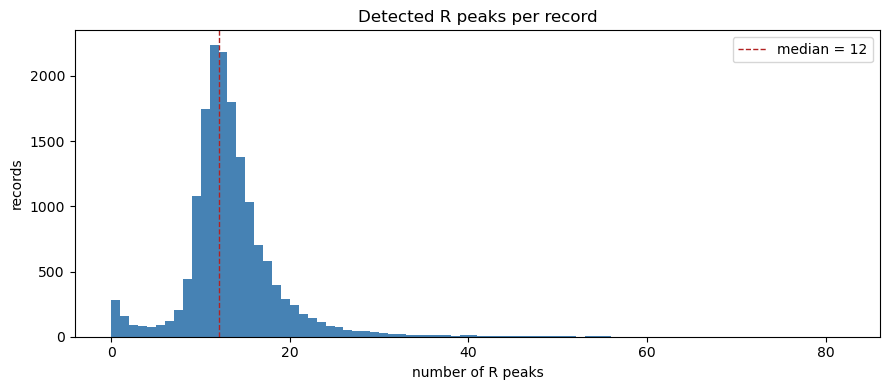

In [99]:
FEATURES = [c for c in features.columns if c != "label"]
lengths = features[FEATURES].map(len)

# Difficulty 1: "at some points, all the features for the particular subjects are NaN".
empty = features[FEATURES].map(
    lambda a: len(a) == 0 or bool(np.all(np.isnan(a)))).all(axis = 1)

print(f"Difficulty 1 - subjects with every feature NaN: {empty.sum():,} ({empty.mean():.1%})")

# Difficulty 2: "the length of extracted features for all the ECGs are not the same,
# which means all the recorded signals did not have equal no. of peaks".
n_beats = lengths["R_loc"]

print(f"Difficulty 2 - distinct feature lengths: {n_beats.nunique()}"
      f"  (min {n_beats.min()}, median {int(n_beats.median())}, max {n_beats.max()})")

# In some records, the sixteen features do not always share a length.
ragged = lengths.nunique(axis = 1) > 1

print(f"Also         - records whose 16 features disagree in length: {ragged.sum():,}")
print(f"               all of them have exactly one R-peak: "
      f"{bool((ragged == (n_beats == 1)).all())}")

print("\nmean share of NaN within each feature:")
print(features[FEATURES]
      .map(lambda a: float(np.mean(np.isnan(a))) if len(a) else 1.0)
      .mean().sort_values(ascending = False).round(3).to_string())


fig, ax = plt.subplots(figsize = (9, 4))

ax.hist(n_beats, bins = range(0, int(n_beats.max()) + 2), color = "steelblue")
ax.set_title("Detected R peaks per record")
ax.set_xlabel("number of R peaks")
ax.set_ylabel("records")
ax.axvline(int(n_beats.median()), color = "firebrick", linestyle = "--", linewidth = 1,
           label = f"median = {int(n_beats.median())}")
ax.legend()

plt.tight_layout()
plt.show()

## Forward fill and length equating

The paper applies the fixes in a stated order: *"To deal with the missing values in the extracted feature, the Forward Fill (ffill) method has been implemented at this stage. Next, the length of extracted features for each ECG signal is equated."*

Forward fill therefore runs first, along the beat axis inside each record, which is the only axis available while the lists are still ragged. Lengths are then equated so the sixteen features can be stacked into the three-dimensional array, and that array is flattened to one row per subject.

The paper does not state the common length, so `N_BEATS` is set to the median peak count measured above. A second forward fill down the columns follows, because the first pass cannot repair the 280 subjects whose features are entirely NaN - the paper lists those as its first difficulty, and only an across-subject fill can reach them.

In [100]:
N_BEATS = int(n_beats.median())


def forward_fill(values):
    """Forward fill along the beat axis of one record."""
    if len(values) == 0:
        return values
    index = np.where(~np.isnan(values), np.arange(len(values)), 0)
    np.maximum.accumulate(index, out = index)
    return values[index]


def equate(values, length):
    """Truncate or pad one record to a common number of beats."""
    out = np.full(length, np.nan, dtype = np.float32)
    keep = min(len(values), length)
    if keep:
        out[:keep] = values[:keep]
        out[keep:] = values[keep - 1]     # forward fill past the last beat
    return out


cube = np.stack([
    np.stack([equate(forward_fill(features[c].iloc[i]), N_BEATS) for c in FEATURES])
    for i in range(len(features))
])

print(f"three-dimensional array: {cube.shape}  (subjects, features, beats)")

columns = [f"{c}_{k}" for c in FEATURES for k in range(N_BEATS)]
prepared = pd.DataFrame(cube.reshape(len(cube), -1), index = features.index,
                        columns = columns)

print(f"flattened:               {prepared.shape}")
print(f"NaN before column fill:  {prepared.isna().mean().mean():.2%}"
      f"   all-NaN subjects: {prepared.isna().all(axis = 1).sum()}")

prepared = prepared.ffill()

# RR_0 is undefined for every record, so forward fill has nothing to draw from.
dead = prepared.columns[prepared.isna().all()]
prepared = prepared.drop(columns = dead)

print(f"NaN after column fill:   {prepared.isna().sum().sum()}"
      f"   dropped all-NaN columns: {list(dead)}")
print(f"final feature matrix:    {prepared.shape}")

three-dimensional array: (16244, 16, 12)  (subjects, features, beats)
flattened:               (16244, 192)
NaN before column fill:  3.96%   all-NaN subjects: 280
NaN after column fill:   0   dropped all-NaN columns: ['RR_0']
final feature matrix:    (16244, 191)


In [101]:
prepared

,P_loc_0,P_loc_1,P_loc_2,P_loc_3,P_loc_4,P_loc_5,P_loc_6,P_loc_7,P_loc_8,P_loc_9,...,RR_2,RR_3,RR_4,RR_5,RR_6,RR_7,RR_8,RR_9,RR_10,RR_11
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,264.0,1363.0,2484.0,3063.0,3469.0,3589.0,4705.0,5712.0,5844.0,6687.0,...,1116.0,707.0,278.0,115.0,1116.0,1008.0,136.0,980.0,160.0,1004.0
2,1183.0,2769.0,4387.0,6029.0,7525.0,8965.0,10339.0,11933.0,11933.0,11933.0,...,1628.0,1624.0,1500.0,1440.0,1388.0,1584.0,1584.0,1584.0,1584.0,1584.0
3,84.0,1237.0,1947.0,2413.0,3565.0,4716.0,5820.0,6924.0,8029.0,9156.0,...,1006.0,170.0,1152.0,1152.0,1097.0,1104.0,1111.0,1128.0,1116.0,1128.0
4,344.0,1297.0,2288.0,3345.0,4377.0,5341.0,6253.0,7213.0,8149.0,9153.0,...,996.0,1056.0,1032.0,968.0,912.0,952.0,944.0,1000.0,936.0,912.0
5,393.0,1481.0,2633.0,3745.0,4781.0,5777.0,6845.0,8033.0,9173.0,10253.0,...,1152.0,1116.0,1040.0,996.0,1068.0,1180.0,1140.0,1080.0,1008.0,1008.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,92.0,262.0,756.0,932.0,1238.0,1370.0,1604.0,2055.0,2276.0,2772.0,...,498.0,174.0,389.0,105.0,178.0,458.0,214.0,498.0,162.0,577.0
21834,180.0,572.0,1246.0,2304.0,3372.0,4452.0,5518.0,6576.0,7666.0,8760.0,...,354.0,1057.0,1068.0,1080.0,1068.0,1055.0,1093.0,1092.0,1080.0,1068.0
21835,20.0,74.0,153.0,361.0,532.0,901.0,1485.0,1552.0,1624.0,2089.0,...,105.0,228.0,156.0,280.0,635.0,72.0,60.0,421.0,491.0,698.0


## Labels and train/test split

*"the set of all the n features for each subject is combined with respective labels with
the help of subject IDs. The labels or target variables are in string format; hence, it is
converted to the numeric data type by applying label encoding."*

In [102]:
LABEL_ENCODING = {"NORM": 0, "MI": 1, "STTC": 2, "HYP": 3, "CD": 4}

target = y.loc[prepared.index].map(LABEL_ENCODING)

print("label encoding:")
for name, code in LABEL_ENCODING.items():
    print(f"  {code}  {name:5s} {(target == code).sum():,}")

X_train, X_test, y_train, y_test = train_test_split(
    prepared, target, test_size = 0.2, random_state = 42)

print(f"\ntrain: {X_train.shape}   test: {X_test.shape}")

label encoding:
  0  NORM  9,069
  1  MI    2,532
  2  STTC  2,400
  3  HYP   535
  4  CD    1,708

train: (12995, 191)   test: (3249, 191)


## Train/test class distribution

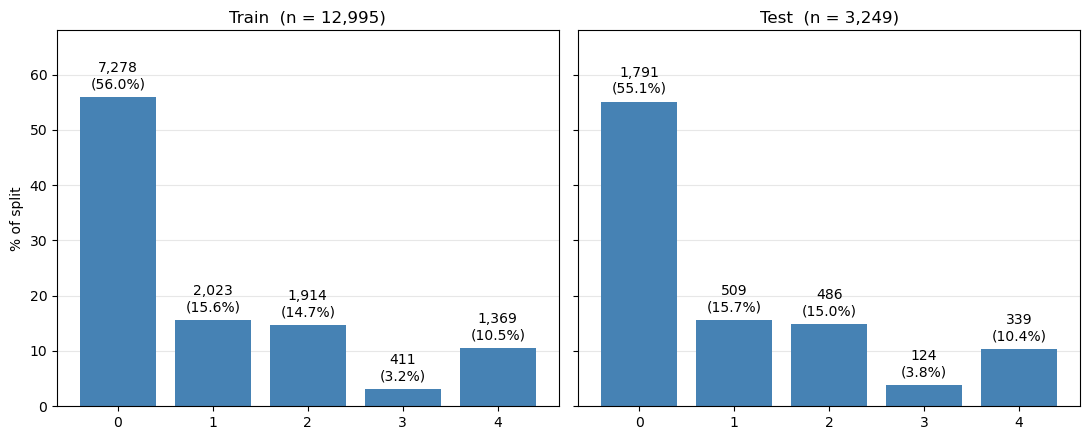

In [103]:
fig, axes = plt.subplots(1, 2, figsize = (11, 4.5), sharey = True)

for ax, (title, split) in zip(axes, [("Train", y_train), ("Test", y_test)]):
    counts = split.value_counts()
    shares = counts / len(split) * 100

    ax.bar(shares.index, shares.values, color = "steelblue")
    ax.set_title(f"{title}  (n = {len(split):,})")
    ax.set_xlabel("")
    ax.grid(axis = "y", alpha = 0.3)
    ax.set_axisbelow(True)

    for pos, share, count in zip(shares.index, shares.values, counts.values):
        ax.text(pos, share + 1, f"{count:,}\n({share:.1f}%)", ha = "center", va = "bottom")

axes[0].set_ylabel("% of split")
axes[0].set_ylim(0, 68)

plt.tight_layout()
plt.show()

# Data Augmentation

*"The process of data augmentation includes the oversampling of the minority class in the
training data. To up-sample the minority class, SMOTE (Synthetic Minority Over-sampling
Technique) is used here... The process of data augmentation and feature scaling is done
only on 80 % of training data, which are selected randomly in each fold of the 10-fold
cross-validation process."*

Two requirements follow from that sentence. Resampling and scaling touch the **training
data only**, never the held-out test set, and they are refitted **inside every fold**
rather than once up front, otherwise synthetic minority samples derived from validation
rows would leak into training.

train before SMOTE: (12995, 191)
train after  SMOTE: (36390, 191)
test set untouched: (3249, 191)


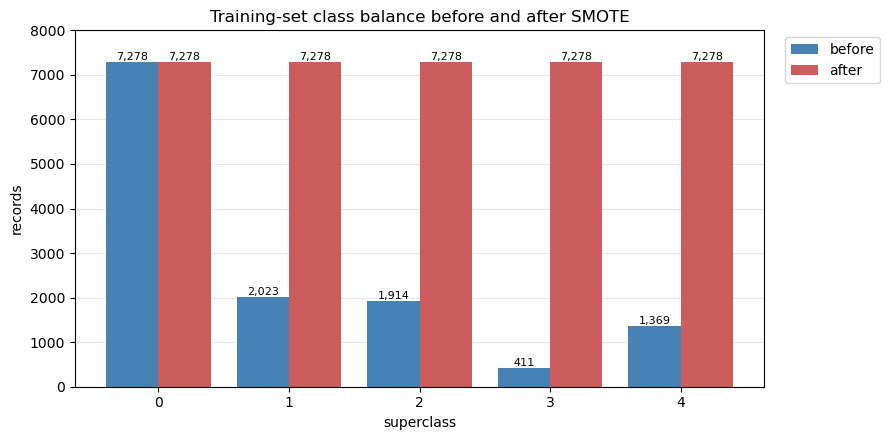

In [104]:
before = y_train.value_counts()

X_scaled = StandardScaler().fit_transform(X_train)
X_resampled, y_resampled = SMOTE(random_state = 42).fit_resample(X_scaled, y_train)

after = pd.Series(y_resampled).value_counts()

print(f"train before SMOTE: {X_train.shape}")
print(f"train after  SMOTE: {X_resampled.shape}")
print(f"test set untouched: {X_test.shape}")


fig, ax = plt.subplots(figsize = (9, 4.5))

width = 0.4
ax.bar(before.index - width / 2, before.values, width, label = "before", color = "steelblue")
ax.bar(after.index + width / 2, after.values, width, label = "after",
       color = "indianred")

ax.set_title("Training-set class balance before and after SMOTE")
ax.set_ylabel("records")
ax.set_xlabel("superclass")
ax.set_ylim(0, 8000)
ax.grid(axis = "y", alpha = 0.3)
ax.set_axisbelow(True)
ax.legend(loc = "upper left", bbox_to_anchor = (1.02, 1))

for pos, b, a in zip(before.index, before.values, after.values):
    ax.text(pos - width / 2, b, f"{b:,}", ha = "center", va = "bottom", fontsize = 8)
    ax.text(pos + width / 2, a, f"{a:,}", ha = "center", va = "bottom", fontsize = 8)

plt.tight_layout()
plt.show()

The pipeline below is what the Modeling section uses. An `imblearn` pipeline applies
`SMOTE` during `fit` but not during `predict`, so each fold is trained on resampled data
and scored on the untouched fold.

In [105]:
def augmented(classifier):
    """Scale, then oversample, then fit - refitted inside every fold."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state = 42)),
        ("classifier", classifier),
    ])

# Modeling

The paper describes two incompatible protocols, so both are reproduced.

*"Training data has 80 % of the total data while testing data has 20 %"* (III.D) produces
the confusion matrices of Figure 7, while *"The mean of 10-fold cross-validation for all
five classifiers' performance is listed in Table 6, 7, 9, 10, and 11"* (IV) produces the
per-class tables. The per-class numbers you compare against are therefore the
cross-validated ones.

The five classifiers are those of III.F, all at library defaults since the paper reports no
hyperparameters. Every fit goes through the `augmented()` pipeline, so scaling and SMOTE
are refitted on the training portion alone.

In [106]:
# III.F: "five machine learning algorithms have used, which are KNN, RF, XG-Boost,
# Gradient Boost, and Cat-Boost". Defaults throughout; no tuning.
CLASSIFIERS = {
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(random_state = 42, n_jobs = -1),
    "XGBoost": XGBClassifier(random_state = 42, n_jobs = -1),
    "HistGradientBoost": HistGradientBoostingClassifier(random_state = 42),
    "CatBoost": CatBoostClassifier(random_state = 42, verbose = 0),
    "AdaBoost": AdaBoostClassifier(random_state = 42)
}

# Class codes, in the numeric order of Table 5.
CLASS_ORDER = sorted(LABEL_ENCODING.values())

## Single 80/20 split

In [107]:
holdout = {}

for name, classifier in CLASSIFIERS.items():
    started = time.perf_counter()

    pipeline = augmented(classifier)
    pipeline.fit(X_train, y_train)
    predicted = pipeline.predict(X_test)

    holdout[name] = {
        "accuracy": accuracy_score(y_test, predicted),
        "report": pd.DataFrame(classification_report(
            y_test, predicted, labels = CLASS_ORDER,
            output_dict = True, zero_division = 0)).T,
        "predicted": predicted,
        "proba": pipeline.predict_proba(X_test),
    }

    print(f"{name:14s} accuracy {holdout[name]['accuracy']:.3f}"
          f"   {time.perf_counter() - started:6.1f}s")

KNN            accuracy 0.274      0.6s
RF             accuracy 0.551      5.6s
XGBoost        accuracy 0.586      5.2s
HistGradientBoost accuracy 0.595     14.6s
CatBoost       accuracy 0.587     27.2s
AdaBoost       accuracy 0.292     27.8s


## 10-fold cross-validation

Metrics are averaged across folds, matching *"The mean of 10-fold cross-validation"*.
The paper does not stratify, so `KFold` is used rather than `StratifiedKFold`.

In [108]:
FOLDS = 10


def cross_validate(classifier, X, y, folds = FOLDS):
    """Mean per-class precision, recall and F1 over the folds."""
    kfold = KFold(n_splits = folds, shuffle = True, random_state = 42)
    scores, accuracies = [], []

    for train_index, validation_index in kfold.split(X):
        pipeline = augmented(classifier)
        pipeline.fit(X.iloc[train_index], y.iloc[train_index])
        predicted = pipeline.predict(X.iloc[validation_index])

        actual = y.iloc[validation_index]
        precision, recall, f1, _ = precision_recall_fscore_support(
            actual, predicted, labels = CLASS_ORDER, zero_division = 0)

        scores.append(np.vstack([precision, recall, f1]))
        accuracies.append(accuracy_score(actual, predicted))

    table = pd.DataFrame(np.mean(scores, axis = 0).T, index = CLASS_ORDER,
                         columns = ["precision", "recall", "f1"])
    return table, float(np.mean(accuracies)), float(np.std(accuracies))


crossvalidated = {}

for name, classifier in CLASSIFIERS.items():
    started = time.perf_counter()

    table, mean_accuracy, std_accuracy = cross_validate(classifier, prepared, target)
    crossvalidated[name] = {"report": table, "accuracy": mean_accuracy,
                            "accuracy_std": std_accuracy}

    print(f"{name:14s} accuracy {mean_accuracy:.3f} +/- {std_accuracy:.3f}"
          f"   {time.perf_counter() - started:6.1f}s")

KNN            accuracy 0.277 +/- 0.005      2.3s
RF             accuracy 0.546 +/- 0.009     57.2s
XGBoost        accuracy 0.590 +/- 0.013     49.5s
HistGradientBoost accuracy 0.596 +/- 0.009    140.7s
CatBoost       accuracy 0.590 +/- 0.011    282.7s
AdaBoost       accuracy 0.356 +/- 0.021    322.2s


# Reproduced results

Each output below corresponds to one artefact in the paper.

| here | paper |
| --- | --- |
| per-class table | Tables 6, 7, 9, 10, 11 (10-fold means) |
| summary table | Table 12 (classifier comparison) |
| confusion matrix | Figure 7 (20 % holdout) |
| ROC curves | Figure 8 (class-wise ROC-AUC) |

The per-class table comes from cross-validation and the confusion matrix from the
holdout, because that is how the paper produced each of them.

In [109]:
# Tables 6, 7, 9, 10, 11 - per-class precision, recall and F1, averaged over folds.
per_class = pd.concat({name: result["report"] for name, result in crossvalidated.items()},
                      names = ["classifier", "class"])

(per_class * 100).round(1)

precision  recall    f1
classifier        class                         
KNN               0           64.7    23.7  34.7
                  1           19.8    35.6  25.4
                  2           18.5    29.3  22.7
                  3           16.7    34.9  22.5
                  4           16.3    32.8  21.7
RF                0           66.0    76.1  70.7
                  1           37.0    27.7  31.7
                  2           29.6    23.9  26.4
                  3           30.4    40.7  34.6
                  4           39.1    27.9  32.5
XGBoost           0           65.0    86.9  74.3
                  1           45.4    28.1  34.7
                  2           34.5    16.8  22.4
                  3           40.8    26.6  32.0
                  4           45.0    26.6  33.4
HistGradientBoost 0           65.1    87.6  74.7
                  1           45.9    26.1  33.2
                  2           35.7    16.8  22.7
                  3           40.8    32.3  35.8
                  4           48.0    28.9  36.0
CatBoost          0           66.0    85.0  74.3
                  1           44.4    31.0  36.5
                  2           35.1    19.0  24.5
                  3           35.9    29.7  32.1
                  4           46.3    28.3  35.0
AdaBoost          0           67.4    39.8  49.9
                  1           21.6    27.2  23.9
                  2           22.0    29.8  25.2
                  3           14.8    62.9  23.9
                  4           20.3    25.1  22.3

In [ ]:
# Table 12 - one row per classifier.
summary = pd.DataFrame({
    name: {
        "accuracy": result["accuracy"],
        "accuracy_std": result["accuracy_std"],
        "precision": result["report"]["precision"].mean(),
        "recall": result["report"]["recall"].mean(),
        "f1": result["report"]["f1"].mean(),
    }
    for name, result in crossvalidated.items()
}).T.sort_values("f1", ascending = False)

(summary * 100).round(1)

,accuracy,accuracy_std,precision,recall,f1
HistGradientBoost,59.6,0.9,47.1,38.3,40.5
CatBoost,59.0,1.1,45.5,38.6,40.5
XGBoost,59.0,1.3,46.1,37.0,39.4
RF,54.6,0.9,40.4,39.3,39.2
AdaBoost,35.6,2.1,29.2,37.0,29.0
KNN,27.7,0.5,27.2,31.2,25.4


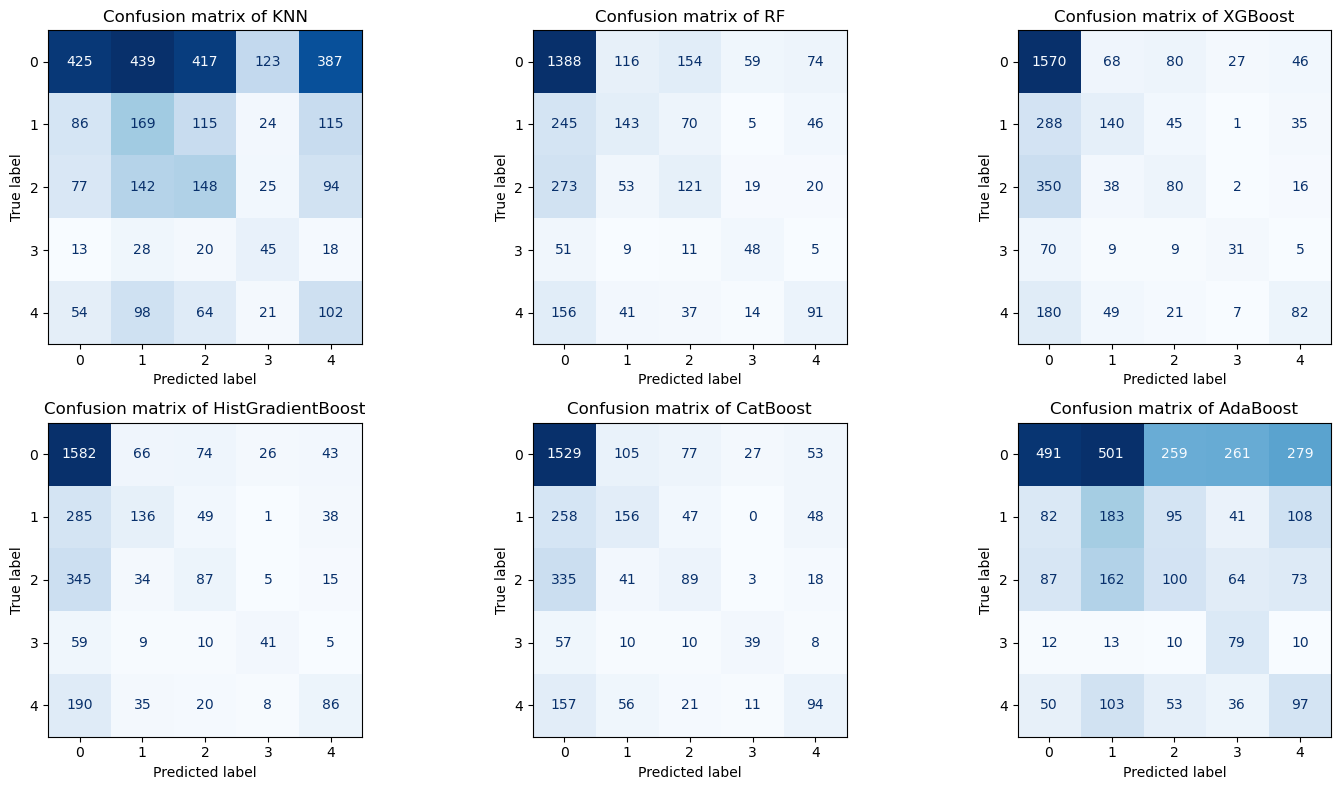

In [118]:
# Figure 7 - confusion matrices on the 20 % holdout, in sample counts.
fig, axes = plt.subplots(2, 3, figsize = (15, 8),
                         squeeze = False)

for ax, (name, result) in zip(axes.ravel(), holdout.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, result["predicted"], labels = CLASS_ORDER,
        values_format = "d", cmap = "Blues", colorbar = False, ax = ax)
    ax.set_title(f"Confusion matrix of {name}")

plt.tight_layout()
plt.show()

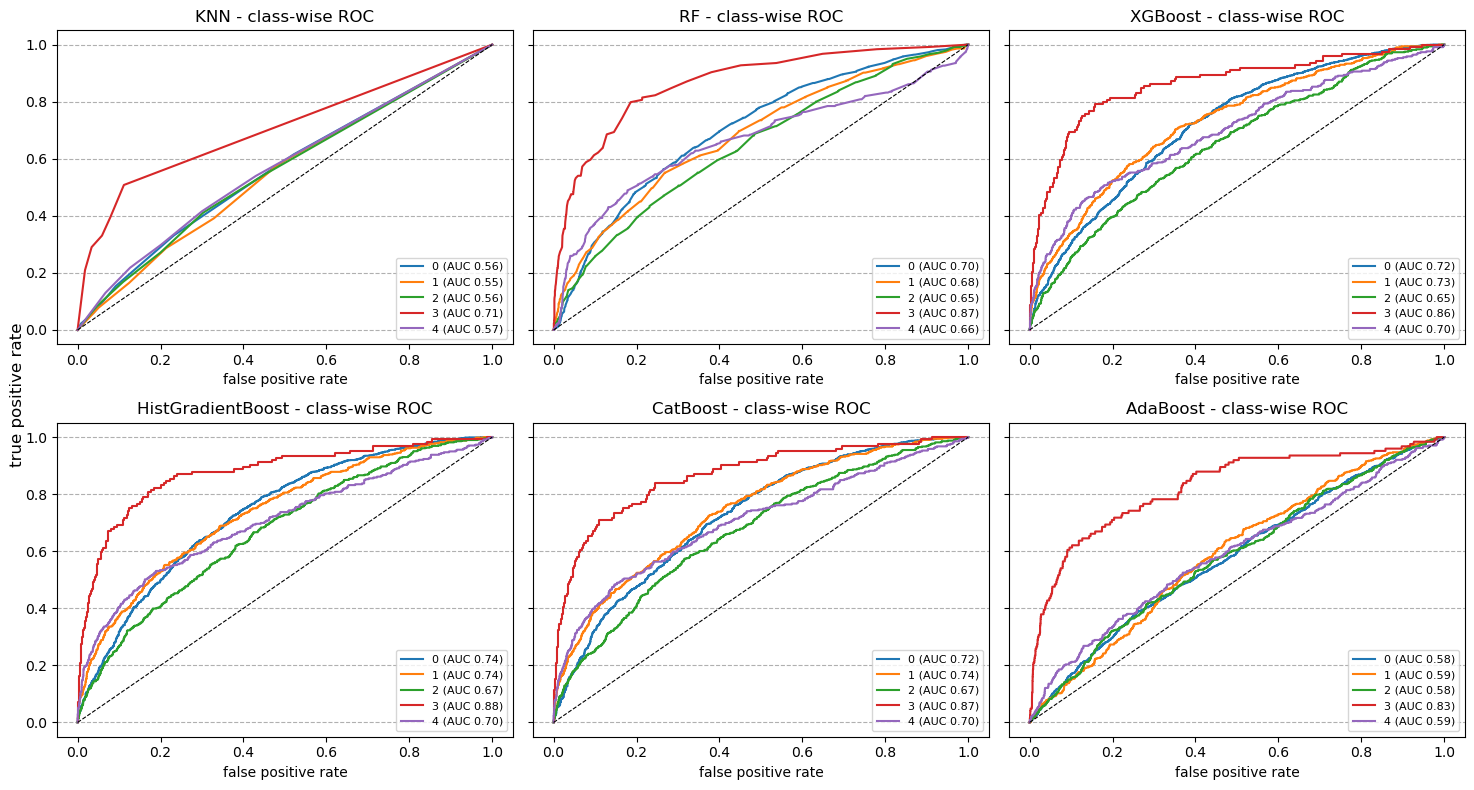

,KNN,RF,XGBoost,HistGradientBoost,CatBoost,AdaBoost
0,0.565,0.702,0.720,0.735,0.724,0.581
1,0.553,0.681,0.729,0.737,0.742,0.594
2,0.560,0.646,0.651,0.670,0.672,0.582
3,0.706,0.868,0.861,0.876,0.866,0.825
4,0.570,0.664,0.698,0.703,0.703,0.588


In [120]:
# Figure 8 - class-wise ROC, one-vs-rest, on the 20 % holdout.
actual = label_binarize(y_test, classes = CLASS_ORDER)

fig, axes = plt.subplots(2, 3, figsize = (15, 8),
                         squeeze = False, sharey = True)

roc_scores = {}

for ax, (name, result) in zip(axes.ravel(), holdout.items()):
    scores = {}
    for k, label in enumerate(CLASS_ORDER):
        false_positive, true_positive, _ = roc_curve(actual[:, k], result["proba"][:, k])
        area = auc(false_positive, true_positive)
        scores[label] = area
        ax.plot(false_positive, true_positive, label = f"{label} (AUC {area:.2f})")

    roc_scores[name] = scores
    ax.plot([0, 1], [0, 1], "k--", linewidth = 0.8)
    ax.set_title(f"{name} - class-wise ROC")
    ax.set_xlabel("false positive rate")
    ax.grid(True, axis = "y", linestyle = "--")
    ax.legend(loc = "lower right", fontsize = 8)

fig.supylabel("true positive rate")
plt.tight_layout()
plt.show()

pd.DataFrame(roc_scores).round(3)